# Train and Tune Convolutional Neural Network Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.cnn import CNNModel
from src.models.factory import Experiment
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, \
    plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.trials
SPLITS = cfg.runtime.splits
rng = set_seed(SEED)

2025-09-07 09:52:32,706 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
df_full

,date,open,high,low,close,volume,adj_close,pos,neu,neg,...,delta_5,delta_10,mom_10,open_l,high_l,low_l,close_l,adj_close_l,volume_l,dow
0,2008-08-22,11426.790039,11632.129883,11426.790039,11628.059570,138790000,11628.059570,0.100609,0.738009,0.161382,...,-31.840821,-106.260742,-0.009097,11415.230469,11476.209961,11315.570312,11430.209961,11430.209961,18.683199,4
1,2008-08-25,11626.190430,11626.269531,11362.629883,11386.250000,148610000,11386.250000,0.003025,0.902580,0.094395,...,-93.139648,-396.099609,-0.034196,11426.790039,11632.129883,11426.790039,11628.059570,11628.059570,18.748473,0
2,2008-08-26,11383.559570,11436.240234,11340.410156,11412.870117,119800000,11412.870117,0.047057,0.693244,0.259698,...,64.320312,-229.599610,-0.019918,11626.190430,11626.269531,11362.629883,11386.250000,11386.250000,18.816836,1
3,2008-08-27,11412.459961,11554.459961,11381.769531,11502.509766,120580000,11502.509766,0.065393,0.834248,0.100360,...,85.080078,-30.450195,-0.002644,11383.559570,11436.240234,11340.410156,11412.870117,11412.870117,18.601334,2
4,2008-08-28,11499.870117,11715.179688,11499.790039,11715.179688,149150000,11715.179688,0.143360,0.775170,0.081470,...,284.969727,99.250000,0.008508,11412.459961,11554.459961,11381.769531,11502.509766,11502.509766,18.607824,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1944,2016-05-13,17711.119141,17734.740234,17512.480469,17535.320312,86640000,17535.320312,0.080107,0.772675,0.147218,...,-205.310547,-238.320313,-0.013499,17711.119141,17798.189453,17625.380859,17720.500000,17720.500000,18.299191,4
1945,2016-05-16,17531.759766,17755.800781,17531.759766,17710.710938,88440000,17710.710938,0.147664,0.442478,0.409857,...,4.800782,-180.449218,-0.010137,17711.119141,17734.740234,17512.480469,17535.320312,17535.320312,18.277272,0
1946,2016-05-17,17701.460938,17701.460938,17469.919922,17529.980469,103260000,17529.980469,0.130503,0.717554,0.151943,...,-398.369140,-220.929687,-0.012524,17531.759766,17755.800781,17531.759766,17710.710938,17710.710938,18.297835,1
1947,2016-05-18,17501.279297,17636.220703,17418.210938,17526.619141,79120000,17526.619141,0.110754,0.562602,0.326644,...,-184.500000,-124.640625,-0.007086,17701.460938,17701.460938,17469.919922,17529.980469,17529.980469,18.452761,2


In [5]:
MODEL_NAME = "cnn"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: CNNModel(horizon=horizon, random_state=seed),
        include_sentiment=True
    )
]

In [6]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=TRIALS, n_splits=SPLITS)

2025-09-07 09:52:32,818 - INFO - src.utils - Global random seed set to 42
2025-09-07 09:52:32,841 - INFO - ModelTrainer - Initialized trainer for cnn
2025-09-07 09:52:42,506 - INFO - ModelTrainer - Initialized trainer for cnn
2025-09-07 09:52:43,434 - INFO - ModelTrainer - Evaluating model...


In [7]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

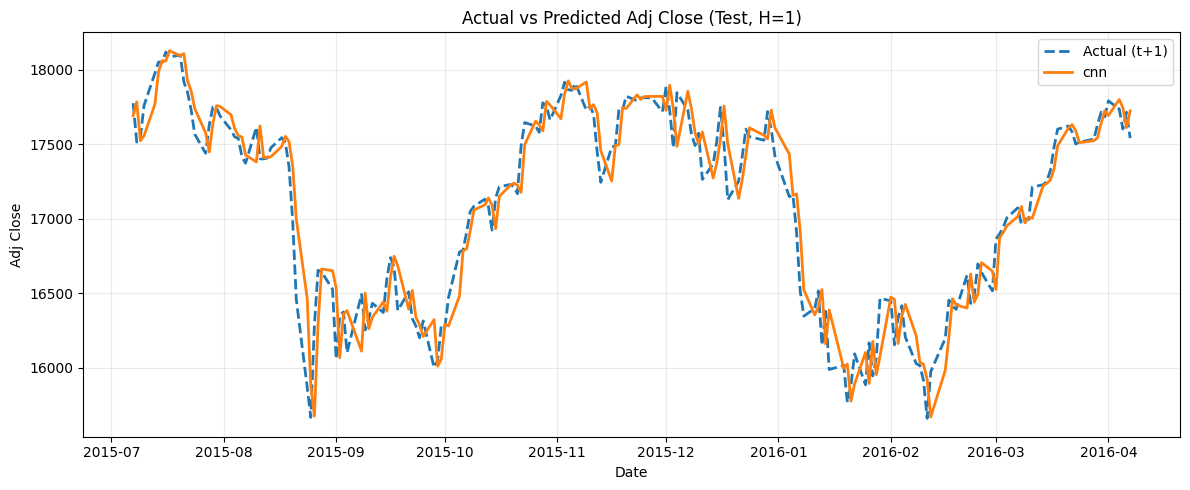

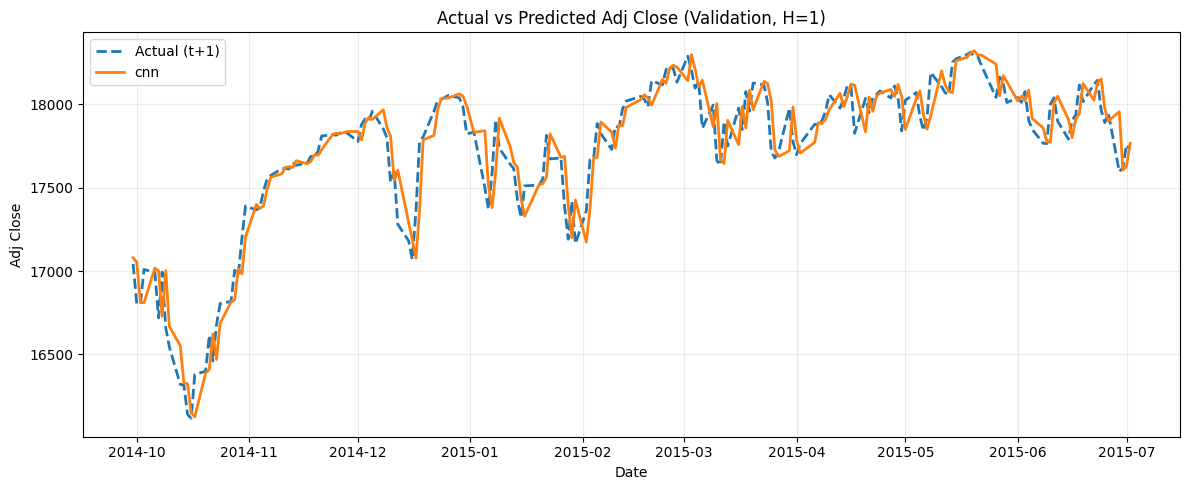

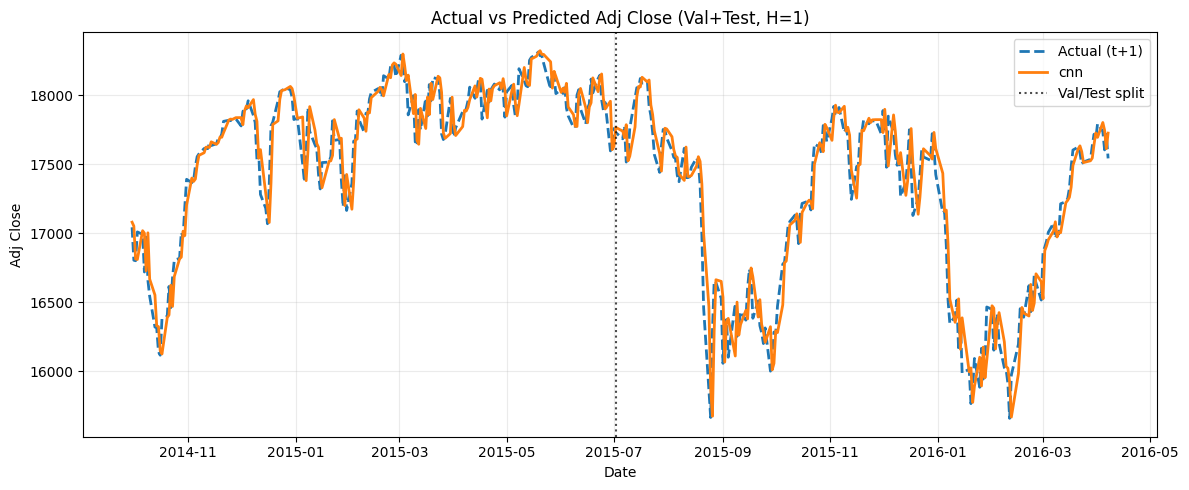

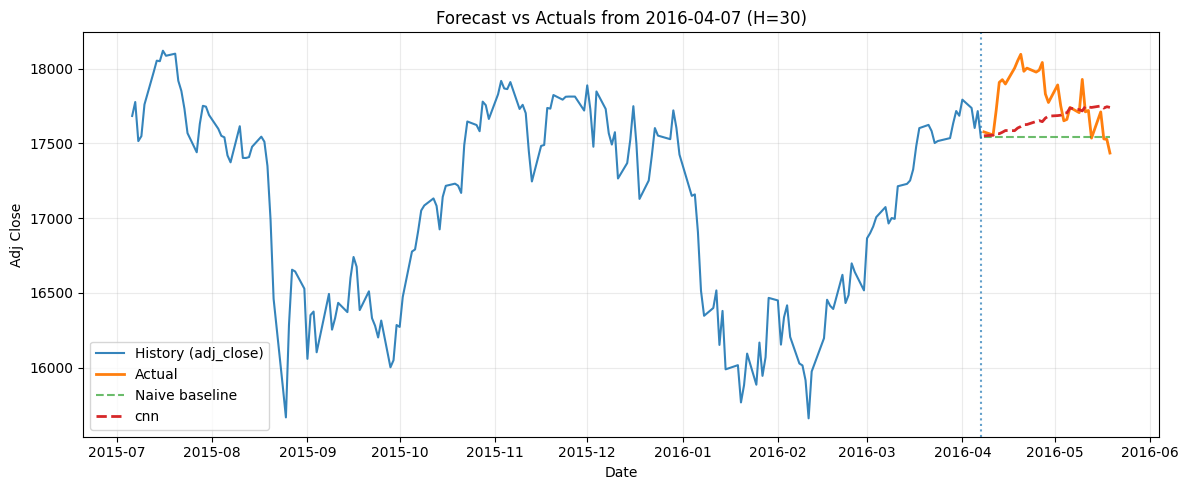

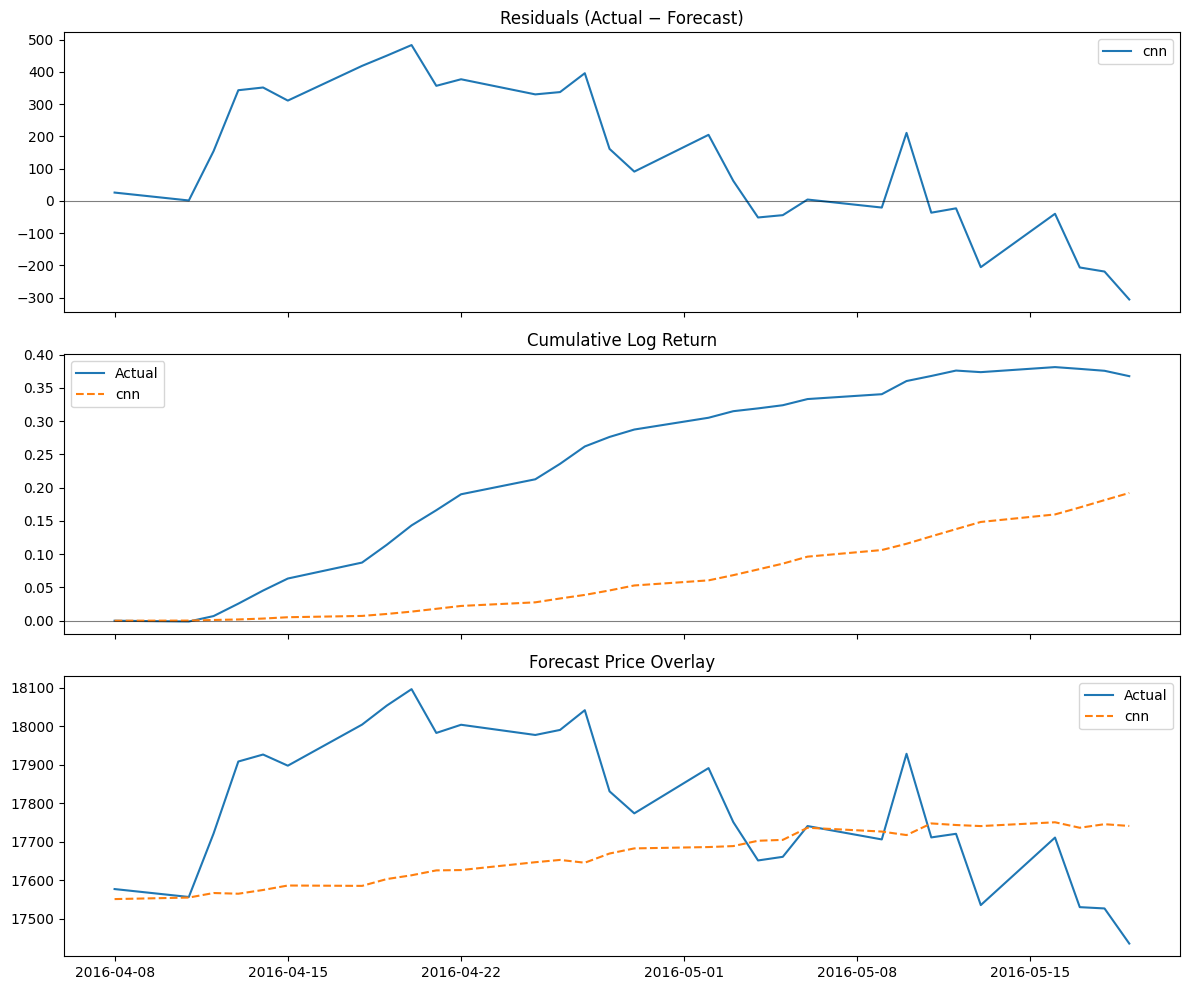

In [8]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [9]:
pd.DataFrame(results[0]["best_params"], index=[0])

,filters,kernel_size,dense_units,dropout,lr,epochs,batch_size,weight_decay,random_state
0,32,4,224,0.324511,0.002041,60,32,0.000003,42


In [10]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,559.745176,550832.751395,742.181077,1.550918,-0.032351


In [11]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()